In [1]:
## the same libraries that we had in "Visualizing_Audio"

import numpy as np
import importlib
import phonlab as phon
from IPython.display import Audio
import matplotlib.pyplot as plt

## New libraries used here for the first time
import parselmouth
import seaborn as sns
import pandas as pd

print(phon.__name__,phon.__version__)

phonlab 0.0.52


# a. Compute and plot f0 traces

* look at the [phonlab documentation](https://phonlab.readthedocs.io/en/latest/acoustphon.html#pitch-tracking) to see the different pitch tracking functions available.
* note how we can add a trace to the spectrogram by getting the matplotlib axes object from sgram.

In [4]:
example_file = importlib.resources.files('phonlab') / 'data' / 'example_audio' / 'stereo.wav'
local_file = 'dimex/s09003.wav'

x,fs = phon.loadsig(local_file,chansel=[0])
f0df = phon.get_f0(x,fs,f0_range=[181,360])
f0df.head()

,sec,f0,rms,c,HNR,probv,voiced
0,0.008254,361.47541,1.950671,0.761387,5.039102,0.698102,True
1,0.013243,361.47541,-4.622815,0.451643,-0.842690,0.127765,False
2,0.018231,361.47541,2.209348,0.857214,7.784036,0.773886,True
3,0.023220,361.47541,8.369311,0.967268,14.705724,0.961024,True
4,0.028209,361.47541,11.697349,0.951522,12.928742,0.982311,True


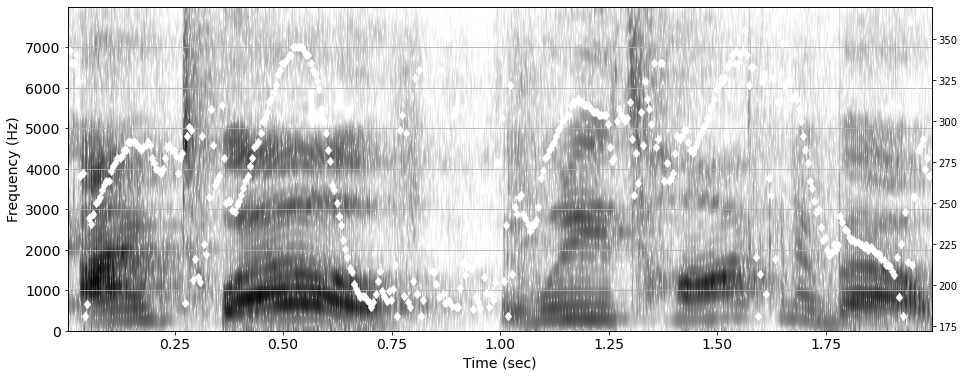

In [7]:

x,fs = phon.loadsig(example_file,chansel=[0])
f0df = phon.get_f0(x,fs,f0_range=[180,360])

# make a plot
ret = phon.sgram(x,fs,cmap='Grays') # draw a spectrogram of the sound
ax1 = ret[0]  # get the plot axis
ax2 = ax1.twinx()  # and twin it for plotting f0
ax2.plot(f0df.sec, f0df.f0, 'wd')  
#ax2.set_ylim(120,360)
Audio(x,rate=fs)

Smoothing result: s = 1.6687295927201962, flag = True


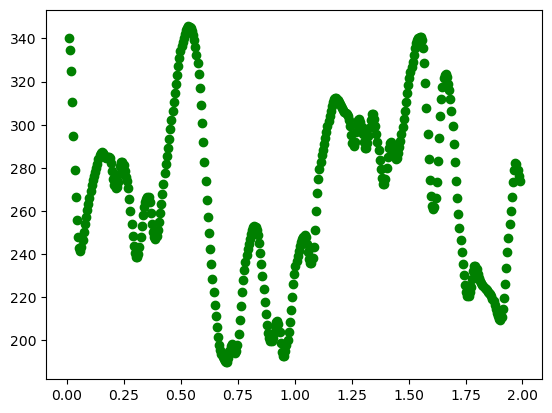

In [8]:
f0df["smoothed_f0"],s,flag = phon.smoothn(f0df.f0,isrobust=True,s=None)
print(f"Smoothing result: s = {s}, flag = {flag}")
plt.plot(f0df.sec, f0df.smoothed_f0, 'go')  

## b. Here's what a pandas dataframe looks like

This is the result of running "get_f0" over the audio samples.

In [9]:
print(f0df)

          sec          f0        rms         c       HNR     probv  voiced  \
0    0.008313  342.857143  26.135822  0.433223 -1.167000  0.997562    True   
1    0.013312  335.664336  26.107795  0.610815  1.957543  0.998653    True   
2    0.018312  335.664336  25.657256  0.623050  2.182392  0.998548    True   
3    0.023312  340.425532  26.190925  0.667174  3.020226  0.998911    True   
4    0.028313  324.324324  30.510659  0.367041 -2.366618  0.999020    True   
..        ...         ...        ...       ...       ...       ...     ...   
392  1.968312  285.714286  39.823108  0.623370  2.188310  0.999963    True   
393  1.973313  289.156627  39.693856  0.555806  0.973502  0.999952    True   
394  1.978312  271.186441  38.434076  0.552294  0.911771  0.999933    True   
395  1.983313  277.456647  35.590863  0.293578 -3.813416  0.999664    True   
396  1.988312  266.666667  35.327096  0.225651 -5.355006  0.999547    True   

     smoothed_f0  
0     340.188857  
1     334.824214  
2     

## Try these exersizes  (refer to the documentation for the various functions)

* Plot the F0 trace with red plus signs
* Plot the RMS amplitude trace instead of the F0 trace
* Plot the F0 trace on it's own, without a spectrogram

# c. Use parselmouth to run Praat pitch tracing.

In [10]:
example_file = importlib.resources.files('phonlab') / 'data/example_audio/stereo.wav'

pitch = parselmouth.Sound(str(example_file)).extract_left_channel().to_pitch()  # create a Praat Sound object
#pitch = snd.to_pitch()  # create a Praat pitch object
f0df_praat = phon.pitch_to_df(pitch)  # convert it into a Pandas dataframe

f0df_praat

,sec,f0
0,0.024062,NaN
1,0.034062,NaN
2,0.044062,NaN
3,0.054062,239.147403
4,0.064062,245.237052
...,...,...
191,1.934063,100.195697
192,1.944063,98.644271
193,1.954063,98.383765
194,1.964063,97.349536


## d. Compare pitch traces 

* this block of code plots F0 that was calculated above in a. (saved in dataframe 'f0df')
* together with the parselmouth F0 trace (saved in dataframe 'f0df_praat')

the median F0 is: 271.0419373190529


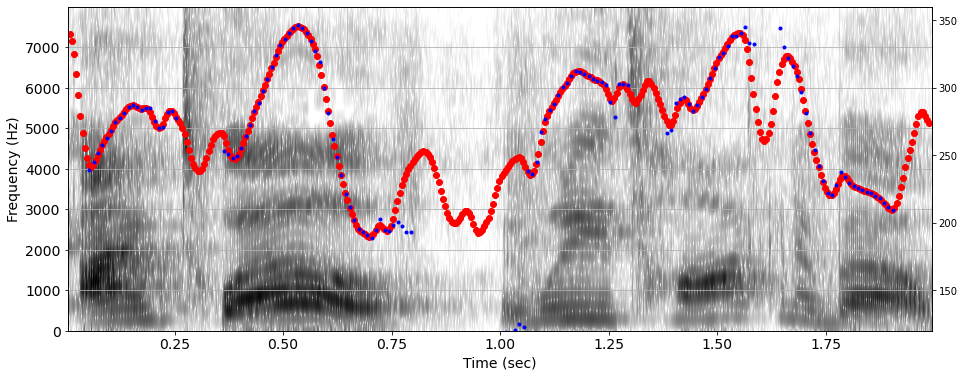

In [11]:
ret = phon.sgram(x,fs,cmap='Greys') # draw a spectrogram of the sound

ax1 = ret[0]  # get the plot axis
ax2 = ax1.twinx()  # and twin it for plotting f0
ax2.plot(f0df.sec, f0df.smoothed_f0, 'ro')  
ax2.plot(f0df_praat.sec, f0df_praat.f0, 'b.')  

ax2.set_ylim(120,360)
f0median = np.median(f0df.smoothed_f0)
print(f"the median F0 is: {f0median}")

# e. Compute and plot formant values

<Axes: xlabel='Time (sec)', ylabel='Frequency (Hz)'>

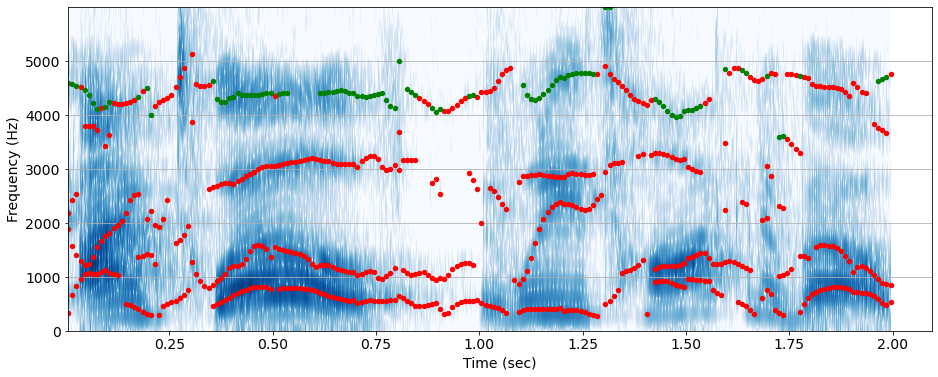

In [23]:
example_file = importlib.resources.files('phonlab') / 'data' / 'example_audio' / 'stereo.wav'

x,fs = phon.loadsig(example_file,chansel=[0])  # read in the audio

fmtdf = phon.TVLP_formants(x,fs,f0median=f0median,order=10)  # compute formant frequencies
#fmtdf = phon.track_formants(x,fs,method="ifc",speaker=1,quiet=False)  # compute formant frequencies

# make a plot
phon.sgram(x,fs, cmap="Blues",tf = 6000)  # plot the spectrogram

# add formant dots to the spectrogram
dot_color = "red"
sns.pointplot(fmtdf,x='sec',y='F1',linestyle='none',
              native_scale=True,marker=".",color=dot_color)
sns.pointplot(fmtdf,x='sec',y='F2',linestyle='none',
              native_scale=True,marker=".",color=dot_color)
sns.pointplot(fmtdf,x='sec',y='F3',linestyle='none',
              native_scale=True,marker=".",color=dot_color)
sns.pointplot(fmtdf,x='sec',y='F4',linestyle='none',
              native_scale=True,marker=".",color="green")

In [23]:
fmtdf.head()

,sec,rms,F1,F2,F3,F4,f0,c
0,0.01,-31.231749,641.526,2041.622,2794.636,4441.482,342.857,0.511
1,0.02,-31.060112,660.512,2096.801,2780.957,4428.634,342.857,0.506
2,0.03,-17.713840,961.425,1999.329,2628.304,4229.030,266.667,0.586
3,0.04,-14.239433,1041.242,1535.969,2786.887,4046.993,134.831,0.579
4,0.05,-12.104159,1050.380,1528.401,2911.185,4000.382,80.537,0.520


## f. Use Praat parselmouth to compute formants

* the figure here compares the formants calculated by track_formants() with those calculated in parselmouth.

<Axes: xlabel='Time (sec)', ylabel='Frequency (Hz)'>

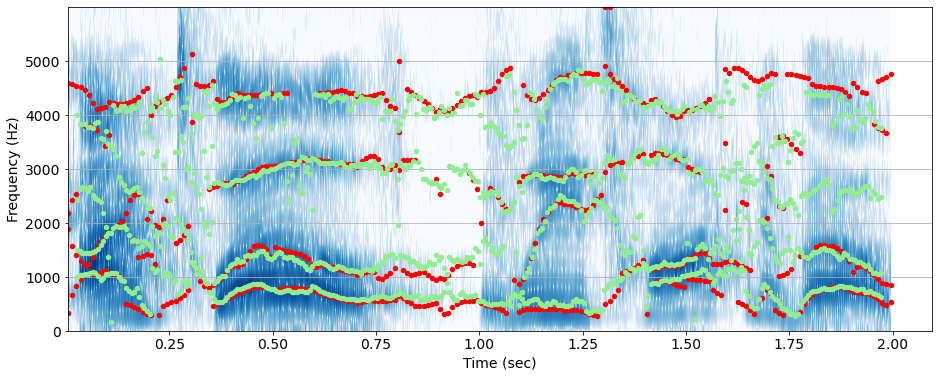

In [24]:
example_file = importlib.resources.files('phonlab') / 'data' / 'example_audio' / 'stereo.wav'

snd = parselmouth.Sound(str(example_file)).extract_left_channel()  # create a Praat Sound object
maxf = 5500       # use 5000 for men, 6000 for women, 8000 for children
fmnt = snd.to_formant_burg(maximum_formant=maxf)  # create a Praat Formant object
fmtdf_praat = phon.formant_to_df(fmnt, 4, include_bw=False)  # convert it into a Pandas dataframe

phon.sgram(x,fs, cmap="Blues",tf=6000)  # plot the spectrogram

# add formant dots to the spectrogram, first for phon.track_formants()
dot_color = "red"
sns.pointplot(fmtdf,x='sec',y='F1',linestyle='none',native_scale=True,marker=".",color=dot_color)
sns.pointplot(fmtdf,x='sec',y='F2',linestyle='none',native_scale=True,marker=".",color=dot_color)
sns.pointplot(fmtdf,x='sec',y='F3',linestyle='none',native_scale=True,marker=".",color=dot_color)
sns.pointplot(fmtdf,x='sec',y='F4',linestyle='none',native_scale=True,marker=".",color=dot_color)

# then for snd.to_formant_burg()
dot_color = "lightgreen"
sns.pointplot(fmtdf_praat,x='sec',y='F1',linestyle='none',native_scale=True,marker=".",color=dot_color)
sns.pointplot(fmtdf_praat,x='sec',y='F2',linestyle='none',native_scale=True,marker=".",color=dot_color)
sns.pointplot(fmtdf_praat,x='sec',y='F3',linestyle='none',native_scale=True,marker=".",color=dot_color)
sns.pointplot(fmtdf_praat,x='sec',y='F4',linestyle='none',native_scale=True,marker=".",color=dot_color)

## Try these exersizes  (refer to the documentation for the various functions)

* Try calculating formants with the IFC option in phon.track_formants - how do these compare with parselmouth?
* What is different when you specify 'quiet=True' in track_formants?
* What columns are present in the fmtdf and fmtdf_praat dataframes?
* Try reproducing the figure above under 'compare pitch traces' but here comparing the pitch trace calculated in the track_formants() function with one of the others.

# g. Measuring fricative spectral properties

The function [phon.fricative()](https://phonlab.readthedocs.io/en/latest/acoustphon.html#consonant-features) implements the widely used 'spectral moments' analysis that was introduced in phonetic studies by Forrest et al. (1985), as well as a major peaks analysis inspired by the work of Christine Shadle.

This block also shows off the spectral slice option in phon.sgram(), a throwback to the original Kay Spectrograph, circa 1955.



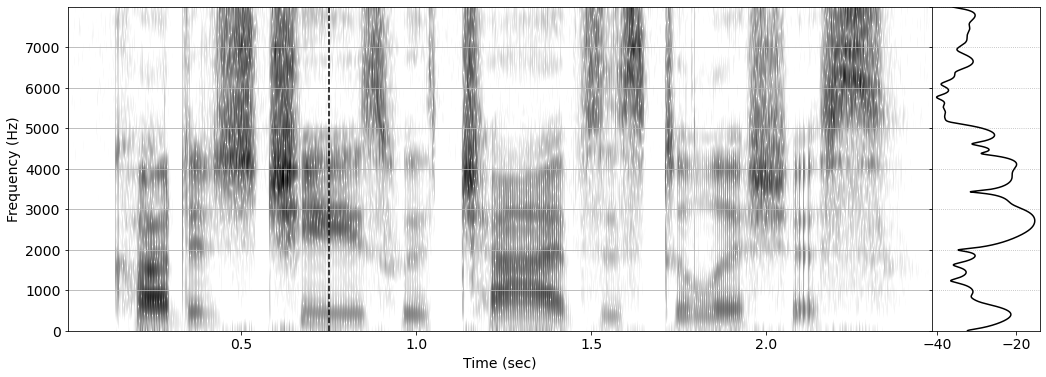

In [25]:
example_file = importlib.resources.files('phonlab') / 'data' / 'example_audio' / 'sf3_cln.wav'

x,fs = phon.loadsig(example_file, chansel=[0])
ret= phon.sgram(x,fs,slice_time=0.75) # note the use of the "slice_time" option
Audio(example_file)

first major peak at 6200.0, Center of Gravity is 5334.7


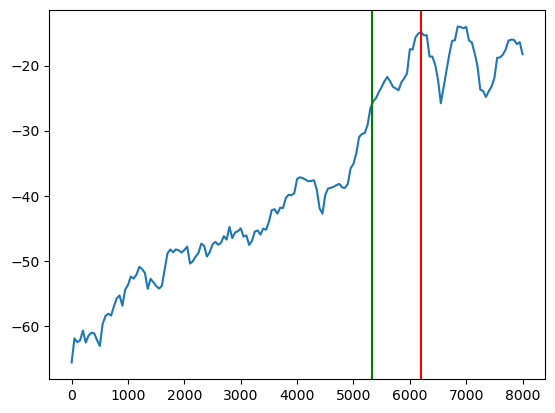

In [26]:
example_file = importlib.resources.files('phonlab') / 'data' / 'example_audio' / 'sf3_cln.wav'

x,fs = phon.loadsig(example_file, chansel=[0])
x,fs = phon.prep_audio(x,fs, target_fs=None, pre=0.94)

analysis_time = 2.235

result = phon.fricative(x,fs,analysis_time)

print(f"first major peak at {result.Fm:.1f}, Center of Gravity is {result.COG:.1f}")
plt.plot(result.freq,result.spec)
plt.axvline(result.Fm,color="red")
plt.axvline(result.COG,color="green")

## Exercises

* pick another fricative in the audio file and compare Fm and COG for that one.
* Look at effect of parameters in the input to the process (sampling frequency and preemphasis)
* what changes with prep_audio(.... , out_type="int")
* compare the Fm and COG values for fricatives at times 0.49, 0.61, 0.88 and 2.23
* inspect the various analysis results (FmB, Am, etc.) for various fricatives.
    * can you format this as a dataframe or spreadsheet

In [27]:
times = [0.49, 0.61]

for t in times:
    result = phon.fricative(x,fs,t)
    print(f"time: {t} -- first major peak at {result.Fm:.1f}, Center of Gravity is {result.COG:.1f}")



time: 0.49 -- first major peak at 4200.0, Center of Gravity is 5173.8
time: 0.61 -- first major peak at 3700.0, Center of Gravity is 4958.8


# h. Finding a stop release burst

* prep_audio() does several thihngs: 
    * add preemphasis,
    * resample to 22050,
    * ensure correct polarity, and s
    * cale to use maximum range

* burst() is trained on the Timit corpus and is a simple linear regression model
    * evidence that the burst is at a location is:
    * b = -1.814 + 0.618*w + 0.045*s
    * where w is size of a waveform peak, and s is magnitude of spectral change

Prep Audio: Resampling from 48000 to 32000
the stop release burst is at time: 0.269 seconds


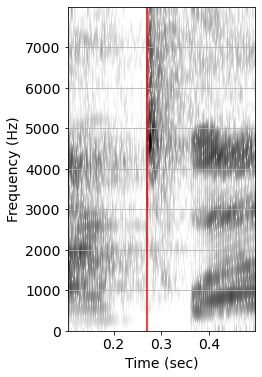

In [28]:
example_file = importlib.resources.files('phonlab') / 'data' / 'example_audio' / 'im_twelve.wav'

x,fs = phon.loadsig(example_file, chansel=[0])  
x,fs = phon.prep_audio(x,fs, pre=0.94) 

# look for a stop release burst in this portion of the audio: time 1 (t1) to time 2 (t2)
t1 = 0.1  # seconds
t2 = 0.5

b_time, b_score = phon.burst(x,fs, t1,t2)  # find a stop burst in the span from t1 to t2
print(f"the stop release burst is at time: {b_time:.3f} seconds")
 
ax1,f,t,Sxx = phon.sgram(x,fs,start=t1, end=t2)
if b_time > 0:  # will be -1 if no burst was found
    ax1.axvline(b_time,color="red")


## Exercise

* try finding bursts in other time chunks, or in other sound files.